<a href="https://colab.research.google.com/github/ST3ALT4/ucs547/blob/main/assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question 1

In [1]:
# Install RAPIDS compatible libraries
!pip install -q cudf-cu12 cuml-cu12 dask-cudf-cu12 --extra-index-url=https://pypi.nvidia.com
!pip install -q cupy-cuda12x xgboost pandas scikit-learn matplotlib seaborn ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import cupy as cp
import cudf
import matplotlib.pyplot as plt
import seaborn as sns
import time

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

from cuml.ensemble import RandomForestClassifier as cuRF

import xgboost as xgb

In [3]:
adult = fetch_ucirepo(id=2)

X = adult.data.features
y = adult.data.targets

cpu_df = pd.concat([X, y], axis=1)

print(cpu_df.head())
print("\nDataset Shape:", cpu_df.shape)

   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

In [4]:
cpu_df.replace(' ?', np.nan, inplace=True)
cpu_df.dropna(inplace=True)

print("Dataset shape after cleaning:", cpu_df.shape)

Dataset shape after cleaning: (47621, 15)


In [5]:
continuous_features = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]

categorical_features = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country'
]

binary_features = ['income']

print("Continuous Features:")
print(continuous_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nBinary Target Feature:")
print(binary_features)

Continuous Features:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical Features:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Binary Target Feature:
['income']


In [6]:
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    cpu_df[col] = le.fit_transform(cpu_df[col].astype(str))
    label_encoders[col] = le

cpu_df['income'] = LabelEncoder().fit_transform(cpu_df['income'])

print(cpu_df.head())

   age  workclass  fnlwgt  education  education-num  marital-status  \
0   39          7   77516          9             13               4   
1   50          6   83311          9             13               2   
2   38          4  215646         11              9               0   
3   53          4  234721          1              7               2   
4   28          4  338409          9             13               2   

   occupation  relationship  race  sex  capital-gain  capital-loss  \
0           1             1     4    1          2174             0   
1           4             0     4    1             0             0   
2           6             1     4    1             0             0   
3           6             0     2    1             0             0   
4          10             5     2    0             0             0   

   hours-per-week  native-country  income  
0              40              39       0  
1              13              39       0  
2              40   

In [7]:
gpu_df = cudf.DataFrame(cpu_df)

print(gpu_df.head())

   age  workclass  fnlwgt  education  education-num  marital-status  \
0   39          7   77516          9             13               4   
1   50          6   83311          9             13               2   
2   38          4  215646         11              9               0   
3   53          4  234721          1              7               2   
4   28          4  338409          9             13               2   

   occupation  relationship  race  sex  capital-gain  capital-loss  \
0           1             1     4    1          2174             0   
1           4             0     4    1             0             0   
2           6             1     4    1             0             0   
3           6             0     2    1             0             0   
4          10             5     2    0             0             0   

   hours-per-week  native-country  income  
0              40              39       0  
1              13              39       0  
2              40   

In [8]:
feature = 'age'

cpu_hist, cpu_bins = np.histogram(cpu_df[feature], bins=10)

age_gpu = cp.asarray(gpu_df[feature].values)

gpu_hist, gpu_bins = cp.histogram(age_gpu, bins=10)

print("CPU Histogram Counts:")
print(cpu_hist)

print("\nGPU Histogram Counts:")
print(cp.asnumpy(gpu_hist))

CPU Histogram Counts:
[8009 8537 8991 9049 5873 3788 2317  716  252   89]

GPU Histogram Counts:
[8009 8537 8991 9049 5873 3788 2317  716  252   89]


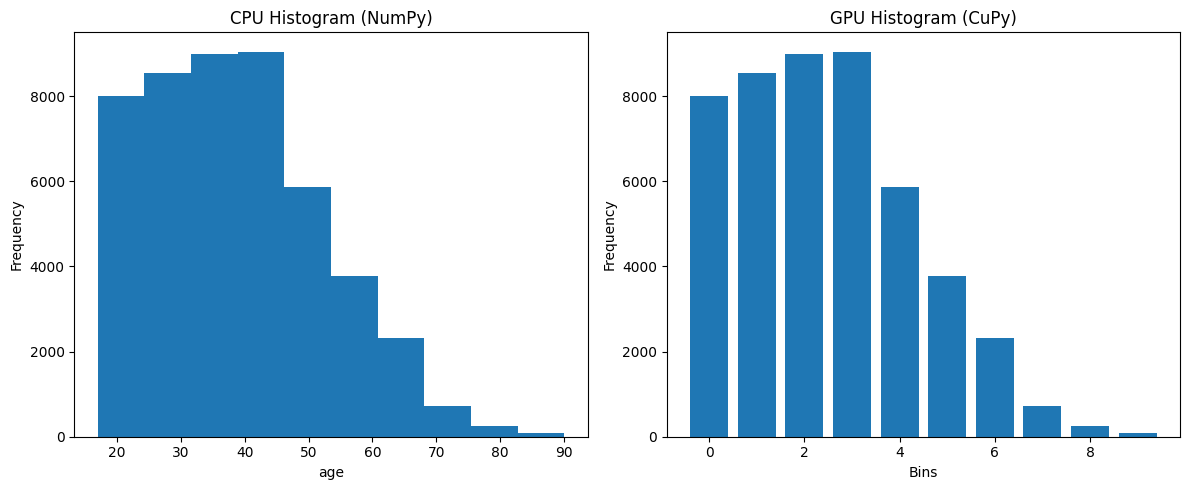

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(cpu_df[feature], bins=10)
plt.title('CPU Histogram (NumPy)')
plt.xlabel(feature)
plt.ylabel('Frequency')

plt.subplot(1,2,2)
plt.bar(range(len(cp.asnumpy(gpu_hist))), cp.asnumpy(gpu_hist))
plt.title('GPU Histogram (CuPy)')
plt.xlabel('Bins')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [10]:
quantiles = cp.percentile(age_gpu, [0, 25, 50, 75, 100])

print("Quantile Bin Edges:")
print(cp.asnumpy(quantiles))

Quantile Bin Edges:
[17. 28. 37. 48. 90.]


In [11]:
binned_age = cp.digitize(age_gpu, quantiles[1:-1])

print("Sample Bin Labels:")
print(cp.asnumpy(binned_age[:20]))

Sample Bin Labels:
[2 3 2 3 1 2 3 3 1 2 2 1 0 1 2 1 0 1 2 2]


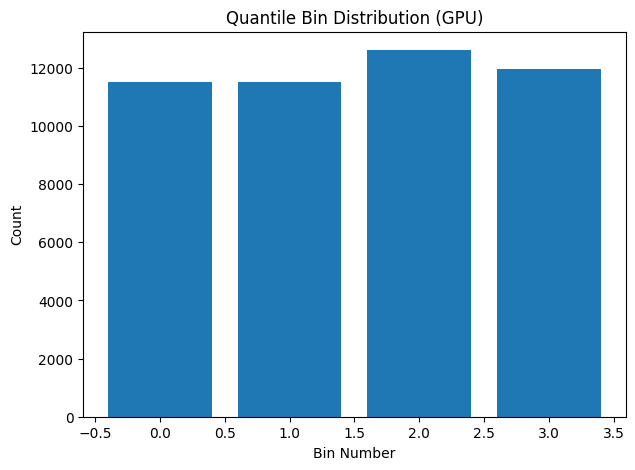

In [12]:
bin_counts = cp.bincount(binned_age)

plt.figure(figsize=(7,5))
plt.bar(range(len(cp.asnumpy(bin_counts))), cp.asnumpy(bin_counts))
plt.title('Quantile Bin Distribution (GPU)')
plt.xlabel('Bin Number')
plt.ylabel('Count')
plt.show()

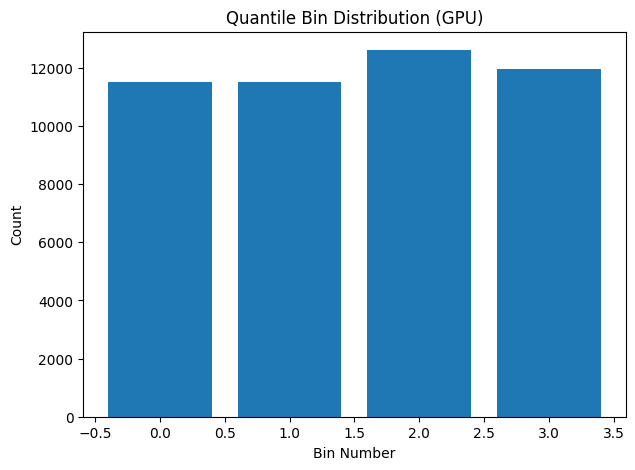

In [13]:
bin_counts = cp.bincount(binned_age)

plt.figure(figsize=(7,5))
plt.bar(range(len(cp.asnumpy(bin_counts))), cp.asnumpy(bin_counts))
plt.title('Quantile Bin Distribution (GPU)')
plt.xlabel('Bin Number')
plt.ylabel('Count')
plt.show()

In [14]:
# Proper binary encoding for target

cpu_df['income'] = cpu_df['income'].astype(str)

cpu_df['income'] = cpu_df['income'].apply(
    lambda x: 1 if '>50K' in x else 0
)

X = cpu_df.drop('income', axis=1)
y = cpu_df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(y.unique())

[0]


In [15]:
cpu_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

start = time.time()
cpu_model.fit(X_train, y_train)
cpu_train_time = time.time() - start

start = time.time()
cpu_preds = cpu_model.predict(X_test)
cpu_pred_time = time.time() - start

cpu_accuracy = accuracy_score(y_test, cpu_preds)

print("CPU Training Time:", cpu_train_time)
print("CPU Prediction Time:", cpu_pred_time)
print("CPU Accuracy:", cpu_accuracy)

CPU Training Time: 0.8766863346099854
CPU Prediction Time: 0.03139376640319824
CPU Accuracy: 1.0


In [16]:
X_train_gpu = cudf.DataFrame(X_train)
X_test_gpu = cudf.DataFrame(X_test)

y_train_gpu = cudf.Series(y_train.values)
y_test_gpu = cudf.Series(y_test.values)

gpu_model = cuRF(
    n_estimators=100,
    random_state=42
)

start = time.time()
gpu_model.fit(X_train_gpu, y_train_gpu)
gpu_train_time = time.time() - start

start = time.time()
gpu_preds = gpu_model.predict(X_test_gpu)
gpu_pred_time = time.time() - start

gpu_preds_np = gpu_preds.to_numpy()

gpu_accuracy = accuracy_score(y_test, gpu_preds_np)

print("GPU Training Time:", gpu_train_time)
print("GPU Prediction Time:", gpu_pred_time)
print("GPU Accuracy:", gpu_accuracy)

GPU Training Time: 2.1702632904052734
GPU Prediction Time: 0.7031891345977783
GPU Accuracy: 1.0


In [17]:
comparison_df = pd.DataFrame({
    'Metric': ['Training Time', 'Prediction Time', 'Accuracy'],
    'CPU': [cpu_train_time, cpu_pred_time, cpu_accuracy],
    'GPU': [gpu_train_time, gpu_pred_time, gpu_accuracy]
})

print(comparison_df)

            Metric       CPU       GPU
0    Training Time  0.876686  2.170263
1  Prediction Time  0.031394  0.703189
2         Accuracy  1.000000  1.000000


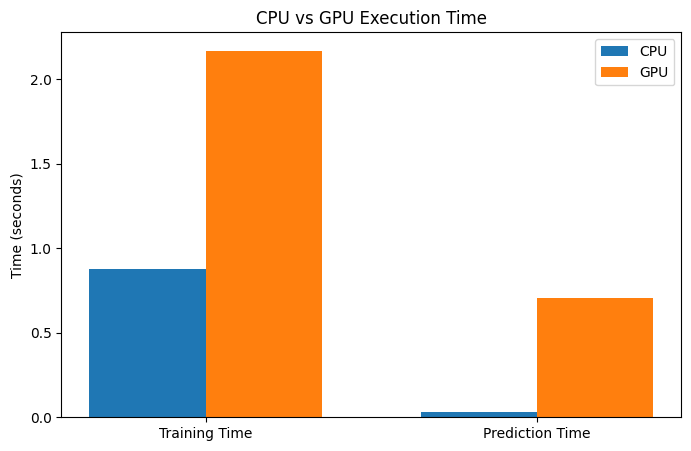

In [18]:
metrics = ['Training Time', 'Prediction Time']

cpu_values = [cpu_train_time, cpu_pred_time]
gpu_values = [gpu_train_time, gpu_pred_time]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, cpu_values, width, label='CPU')
plt.bar(x + width/2, gpu_values, width, label='GPU')

plt.xticks(x, metrics)
plt.ylabel('Time (seconds)')
plt.title('CPU vs GPU Execution Time')
plt.legend()

plt.show()

In [19]:
xgb_train = xgb.DMatrix(X_train, label=y_train)
xgb_test = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'binary:logistic',
    'max_depth': 6,
    'eta': 0.1,
    'eval_metric': 'logloss',
    'tree_method': 'hist',
    'device': 'cuda'
}

start = time.time()

xgb_model = xgb.train(
    params,
    xgb_train,
    num_boost_round=100
)

xgb_train_time = time.time() - start

start = time.time()

xgb_preds = xgb_model.predict(xgb_test)

xgb_pred_time = time.time() - start

xgb_preds_binary = (xgb_preds > 0.5).astype(int)

xgb_accuracy = accuracy_score(y_test, xgb_preds_binary)

print("XGBoost GPU Training Time:", xgb_train_time)
print("XGBoost GPU Prediction Time:", xgb_pred_time)
print("XGBoost GPU Accuracy:", xgb_accuracy)

XGBoost GPU Training Time: 0.5237958431243896
XGBoost GPU Prediction Time: 0.051278114318847656
XGBoost GPU Accuracy: 1.0


In [20]:
final_results = pd.DataFrame({
    'Model': ['CPU RandomForest', 'GPU cuML RandomForest', 'GPU XGBoost'],
    'Training Time': [cpu_train_time, gpu_train_time, xgb_train_time],
    'Prediction Time': [cpu_pred_time, gpu_pred_time, xgb_pred_time],
    'Accuracy': [cpu_accuracy, gpu_accuracy, xgb_accuracy]
})

print(final_results)

                   Model  Training Time  Prediction Time  Accuracy
0       CPU RandomForest       0.876686         0.031394       1.0
1  GPU cuML RandomForest       2.170263         0.703189       1.0
2            GPU XGBoost       0.523796         0.051278       1.0


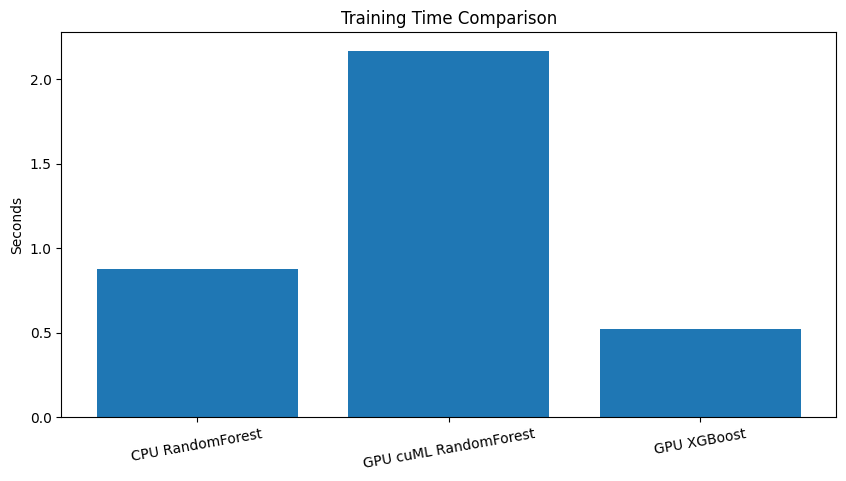

In [21]:
plt.figure(figsize=(10,5))

plt.bar(final_results['Model'], final_results['Training Time'])

plt.title('Training Time Comparison')
plt.ylabel('Seconds')
plt.xticks(rotation=10)

plt.show()

# Question 2

In [22]:
import pandas as pd
import numpy as np
import cupy as cp
import cudf
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

from cuml.ensemble import RandomForestClassifier as cuRF

In [23]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print(X.head())
print("\nDataset Shape:", X.shape)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (455, 30)
Testing Shape: (114, 30)


In [25]:
X_train_gpu = cudf.from_pandas(X_train)
X_test_gpu = cudf.from_pandas(X_test)

y_train_gpu = cudf.Series(y_train.values)
y_test_gpu = cudf.Series(y_test.values)

print(X_train_gpu.head())

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
68         9.029         17.33           58.79      250.5          0.10660   
181       21.090         26.57          142.70     1311.0          0.11410   
63         9.173         13.86           59.20      260.9          0.07721   
248       10.650         25.22           68.01      347.0          0.09657   
60        10.170         14.88           64.55      311.9          0.11340   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
68            0.14130         0.31300              0.04375         0.2111   
181           0.28320         0.24870              0.14960         0.2395   
63            0.08751         0.05988              0.02180         0.2341   
248           0.07234         0.02379              0.01615         0.1897   
60            0.08061         0.01084              0.01290         0.2743   

     mean fractal dimension  ...  worst radius  worst texture  \
68 

In [26]:
cpu_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

start = time.time()

cpu_model.fit(X_train, y_train)

cpu_train_time = time.time() - start

start = time.time()

cpu_preds = cpu_model.predict(X_test)

cpu_pred_time = time.time() - start

cpu_accuracy = accuracy_score(y_test, cpu_preds)

print("CPU Training Time:", cpu_train_time)
print("CPU Prediction Time:", cpu_pred_time)
print("CPU Accuracy:", cpu_accuracy)

CPU Training Time: 0.7707357406616211
CPU Prediction Time: 0.02600264549255371
CPU Accuracy: 0.9649122807017544


In [27]:
gpu_model = cuRF(
    n_estimators=100,
    random_state=42
)

start = time.time()

gpu_model.fit(X_train_gpu, y_train_gpu)

gpu_train_time = time.time() - start

start = time.time()

gpu_preds = gpu_model.predict(X_test_gpu)

gpu_pred_time = time.time() - start

gpu_preds_np = gpu_preds.to_numpy()

gpu_accuracy = accuracy_score(y_test, gpu_preds_np)

print("GPU Training Time:", gpu_train_time)
print("GPU Prediction Time:", gpu_pred_time)
print("GPU Accuracy:", gpu_accuracy)

GPU Training Time: 0.537930965423584
GPU Prediction Time: 1.701348066329956
GPU Accuracy: 0.9649122807017544


In [28]:
speedup = cpu_train_time / gpu_train_time

print("GPU Speedup Over CPU:", speedup)

GPU Speedup Over CPU: 1.4327781633740293


In [29]:
tree_values = [1, 10, 50, 100]

cpu_times = []
gpu_times = []

for trees in tree_values:

    # CPU
    cpu_model = RandomForestClassifier(
        n_estimators=trees,
        random_state=42
    )

    start = time.time()
    cpu_model.fit(X_train, y_train)
    cpu_times.append(time.time() - start)

    # GPU
    gpu_model = cuRF(
        n_estimators=trees,
        random_state=42
    )

    start = time.time()
    gpu_model.fit(X_train_gpu, y_train_gpu)
    gpu_times.append(time.time() - start)

print("CPU Times:", cpu_times)
print("GPU Times:", gpu_times)

CPU Times: [0.018635034561157227, 0.13093852996826172, 0.3135948181152344, 0.48523736000061035]
GPU Times: [0.032949209213256836, 0.10391831398010254, 0.2033224105834961, 0.24317431449890137]


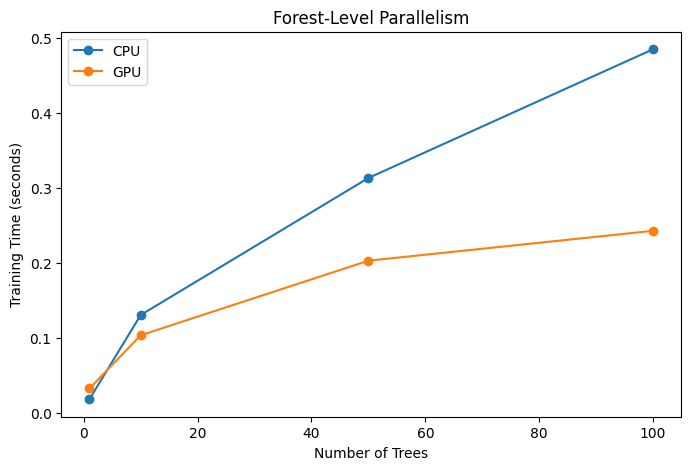

In [30]:
plt.figure(figsize=(8,5))

plt.plot(tree_values, cpu_times, marker='o', label='CPU')
plt.plot(tree_values, gpu_times, marker='o', label='GPU')

plt.xlabel('Number of Trees')
plt.ylabel('Training Time (seconds)')
plt.title('Forest-Level Parallelism')

plt.legend()

plt.show()

In [31]:
feature_importance = cpu_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head())

                 Feature  Importance
23            worst area    0.153892
27  worst concave points    0.144663
7    mean concave points    0.106210
20          worst radius    0.077987
6         mean concavity    0.068001


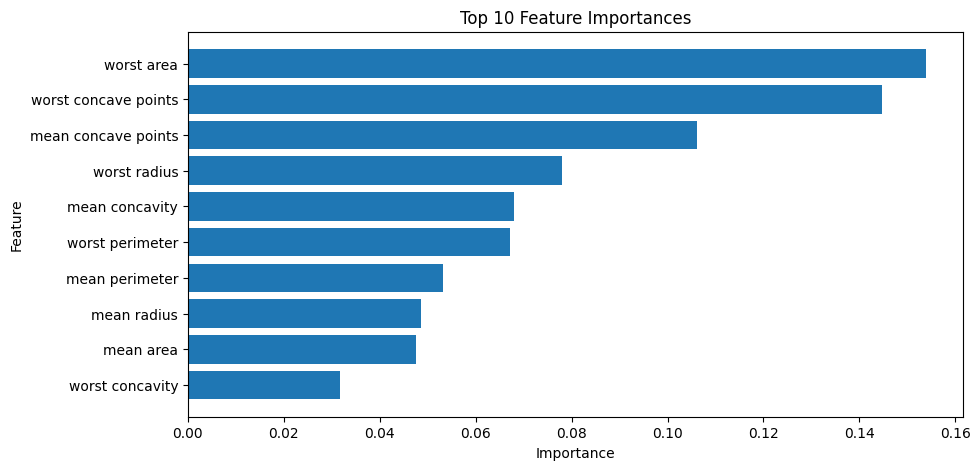

In [32]:
top_features = importance_df.head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')

plt.title('Top 10 Feature Importances')

plt.gca().invert_yaxis()

plt.show()

In [33]:
dataset_sizes = [100, 200, 300, len(X_train)]

gpu_data_times = []

for size in dataset_sizes:

    X_subset = X_train.iloc[:size]
    y_subset = y_train.iloc[:size]

    X_subset_gpu = cudf.from_pandas(X_subset)
    y_subset_gpu = cudf.Series(y_subset.values)

    gpu_model = cuRF(
        n_estimators=100,
        random_state=42
    )

    start = time.time()

    gpu_model.fit(X_subset_gpu, y_subset_gpu)

    gpu_data_times.append(time.time() - start)

print(gpu_data_times)

/usr/local/lib/python3.12/dist-packages/cuml/ensemble/randomforestclassifier.py:247: UserWarning: The number of bins, `n_bins` is greater than the number of samples used for training. Changing `n_bins` to number of training samples.
  return self._fit_forest(X_m, y_m)


[0.19598793983459473, 0.17739272117614746, 0.21212244033813477, 0.19893336296081543]


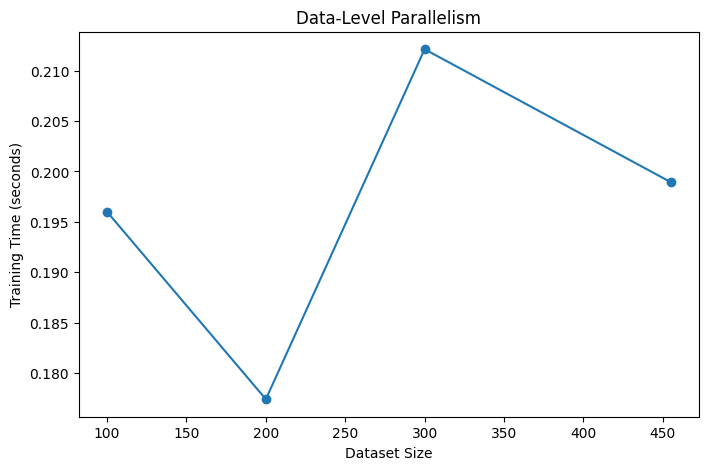

In [34]:
plt.figure(figsize=(8,5))

plt.plot(dataset_sizes, gpu_data_times, marker='o')

plt.xlabel('Dataset Size')
plt.ylabel('Training Time (seconds)')
plt.title('Data-Level Parallelism')

plt.show()

In [35]:
feature = X['mean radius']

feature_gpu = cp.asarray(feature.values)

gpu_hist, gpu_bins = cp.histogram(
    feature_gpu,
    bins=10
)

print("GPU Histogram Counts:")
print(cp.asnumpy(gpu_hist))

GPU Histogram Counts:
[ 19  79 185 129  55  50  38   7   4   3]


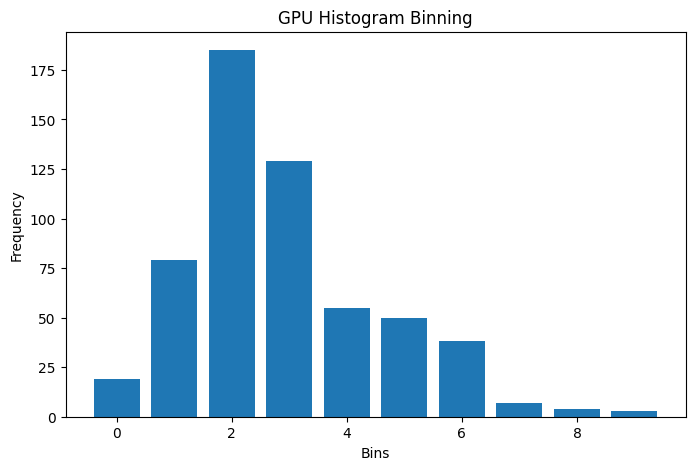

In [36]:
plt.figure(figsize=(8,5))

plt.bar(
    range(len(cp.asnumpy(gpu_hist))),
    cp.asnumpy(gpu_hist)
)

plt.xlabel('Bins')
plt.ylabel('Frequency')

plt.title('GPU Histogram Binning')

plt.show()

In [37]:
comparison_df = pd.DataFrame({
    'Metric': ['Training Time', 'Prediction Time', 'Accuracy'],
    'CPU': [cpu_train_time, cpu_pred_time, cpu_accuracy],
    'GPU': [gpu_train_time, gpu_pred_time, gpu_accuracy]
})

print(comparison_df)

            Metric       CPU       GPU
0    Training Time  0.770736  0.537931
1  Prediction Time  0.026003  1.701348
2         Accuracy  0.964912  0.964912


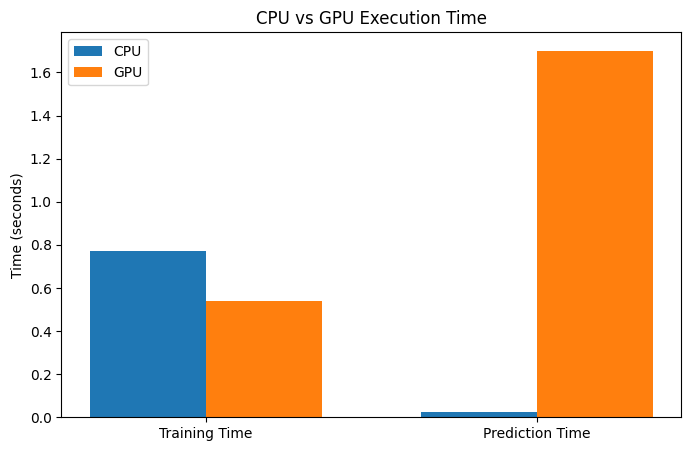

In [38]:
metrics = ['Training Time', 'Prediction Time']

cpu_values = [cpu_train_time, cpu_pred_time]
gpu_values = [gpu_train_time, gpu_pred_time]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, cpu_values, width, label='CPU')
plt.bar(x + width/2, gpu_values, width, label='GPU')

plt.xticks(x, metrics)

plt.ylabel('Time (seconds)')
plt.title('CPU vs GPU Execution Time')

plt.legend()

plt.show()